In [1]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 884.2 kB/s eta 0:00:00


In [2]:
import osmnx

In [ ]:
graph = osmnx.graph.graph_from_place("Poland", network_type='drive')

/usr/local/lib/python3.12/dist-packages/osmnx/_overpass.py:271: UserWarning: This area is 147 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


In [ ]:
graph

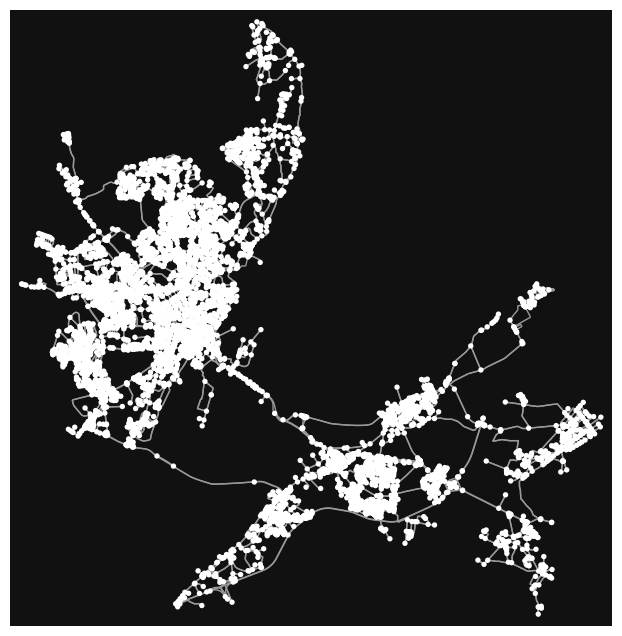

In [ ]:
import matplotlib.pyplot as plt
osmnx.plot_graph(graph)
plt.show()

In [ ]:
import pandas as pd

# Get nodes and edges as GeoDataFrames
nodes, edges = osmnx.graph_to_gdfs(graph)

print("Nodes Data:")
display(nodes.head())

print("\nEdges Data:")
display(edges.head())

Nodes Data:


,y,x,street_count,highway,junction,railway,ref,geometry
osmid,,,,,,,,
253316750,53.430755,14.734969,3,NaN,NaN,NaN,NaN,POINT (14.73497 53.43076)
253804824,53.373248,14.649607,4,NaN,NaN,NaN,NaN,POINT (14.64961 53.37325)
253804829,53.370952,14.647041,3,NaN,NaN,NaN,NaN,POINT (14.64704 53.37095)
253804832,53.372995,14.644516,3,NaN,NaN,NaN,NaN,POINT (14.64452 53.37299)
253804853,53.366953,14.663733,4,NaN,NaN,NaN,NaN,POINT (14.66373 53.36695)



Edges Data:


osmid       highway  \
u         v          key                                                   
253316750 483555486  0              [161226936, 839749385]  unclassified   
          483555474  0    [839749376, 40158540, 839749375]  unclassified   
253804824 286065876  0                            23435298   residential   
          2124488980 0                            27133693      tertiary   
          299143547  0                           160829500      tertiary   

                                name  oneway reversed      length  \
u         v          key                                            
253316750 483555486  0       Kablowa   False     True  285.356650   
          483555474  0           NaN    True    False  862.575775   
253804824 286065876  0    Jęczmienna   False    False  164.832991   
          2124488980 0       Pszenna   False    False  647.091844   
          299143547  0       Pszenna   False     True  131.586082   

                                                                   geometry  \
u         v          key                                                      
253316750 483555486  0    LINESTRING (14.73497 53.43076, 14.73552 53.430...   
          483555474  0    LINESTRING (14.73497 53.43076, 14.73505 53.430...   
253804824 286065876  0    LINESTRING (14.64961 53.37325, 14.6496 53.3732...   
          2124488980 0    LINESTRING (14.64961 53.37325, 14.64982 53.373...   
          299143547  0    LINESTRING (14.64961 53.37325, 14.64944 53.373...   

                         lanes maxspeed  ref width junction bridge access  \
u         v          key                                                    
253316750 483555486  0     NaN      NaN  NaN   NaN      NaN    NaN    NaN   
          483555474  0     NaN      NaN  NaN   NaN      NaN    NaN    NaN   
253804824 286065876  0       2       50  NaN   NaN      NaN    NaN    NaN   
          2124488980 0       2       40  NaN   NaN      NaN    NaN    NaN   
          299143547  0       2       40  NaN   NaN      NaN    NaN    NaN   

                         tunnel  
u         v          key         
253316750 483555486  0      NaN  
          483555474  0      NaN  
253804824 286065876  0      NaN  
          2124488980 0      NaN  
          299143547  0      NaN

In [ ]:
# Process nodes DataFrame
nodes_processed = nodes.reset_index()[['osmid', 'y', 'x']].rename(columns={'osmid': 'id'})

print("Processed Nodes Data:")
display(nodes_processed.head())

Processed Nodes Data:


,id,y,x
0,253316750,53.430755,14.734969
1,253804824,53.373248,14.649607
2,253804829,53.370952,14.647041
3,253804832,53.372995,14.644516
4,253804853,53.366953,14.663733


In [ ]:
# Process edges DataFrame
edges_processed = edges.reset_index()[['u', 'v', 'length']].rename(columns={'length': 'weight'})

print("\nProcessed Edges Data:")
display(edges_processed.head())


Processed Edges Data:


,u,v,weight
0,253316750,483555486,285.356650
1,253316750,483555474,862.575775
2,253804824,286065876,164.832991
3,253804824,2124488980,647.091844
4,253804824,299143547,131.586082


In [ ]:
# Save nodes_processed DataFrame to a CSV file
nodes_processed.to_csv('nodes_processed.csv', index=False)
print("nodes_processed.csv saved successfully.")

nodes_processed.csv saved successfully.


In [ ]:
# Save edges_processed DataFrame to a CSV file
edges_processed.to_csv('edges_processed.csv', index=False)
print("edges_processed.csv saved successfully.")

edges_processed.csv saved successfully.
